<a href="https://colab.research.google.com/github/quiottaso01-alt/4-IAR---Dist---Noc---A---PROCESAMIENTO-DE-HABLA/blob/main/Ivan_Quiottaso_TP2_webscrapping_preprocesamiento.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 PROCESAMIENTO DEL HABLA

**Ivan Enoc Quiottaso**


* Resolver las consignas comentando el código fuente, indicando desde dónde fue extraido o generado.

* Explicar y justificar cada paso realizado.

* Publique enlace público a su notebook en google colab y también enlace a su repositorio github de la materia.


### Entrega de los ejercicios

1. Crea un repositorio GitHub público dedicado a esta materia.
2. Sube tus notebooks de resolución para cada desafío allí.
3. Por cada desafío utilizaremos un sólo notebook.
4. Debes entregar tu TP en el foro correspondiente, siguiendo las instrucciones que allí indica.




## EJERCICIO CONSIGNA

* Cree una nube de palabras de un texto en español.

* Dicho texto puede ser descargado de Internet (webscrapping) o extraído del dataset de alguna librería.

* Puede usar cualquier libreria o herramienta para obtener el texto de su interés.

* En este notebook explica el paso a paso del proceso.



## 1- Webscrapping

Extrae un texto de Internet de una sóla página web usando alguna de las técnicas de webscrapping vistas en clase. Busca el discurso de alguna persona quien te inspire o haya dado una charla motivadora.

No puedes repetir ni usar ni el mismo texto ni la misma web que otra persona quien ya entregó en el foro.

Abajo añade los bloques de código y texto necesarios. Explica paso a paso como descargaste el texto de tu interés.


In [36]:
import requests
from bs4 import BeautifulSoup

# URL del discurso
url = "https://news.harvard.edu/gazette/story/2008/06/text-of-j-k-rowling-speech/"

# Solicitud a la página
response = requests.get(url)

# Parseo del HTML
soup = BeautifulSoup(response.text, "html.parser")

# Extraer todos los párrafos
parrafos = soup.find_all("p")

# Unir todo el texto
texto = " ".join([p.get_text() for p in parrafos])

# Mostrar una parte del texto
print(texto[:1000])

A series of random questions answered by Harvard experts. J.K. Rowling acknowledges applause following the awarding of her honorary degree. Jon Chase/Harvard Staff Photographer 
		J.K. Rowling	 
			Copyright J.K. Rowling		 Text as delivered.  President Faust, members of the Harvard Corporation and the Board of Overseers, members of the faculty, proud parents, and, above all, graduates. The first thing I would like to say is ‘thank you.’ Not only has Harvard given me an extraordinary honour, but the weeks of fear and nausea I have endured at the thought of giving this commencement address have made me lose weight. A win-win situation! Now all I have to do is take deep breaths, squint at the red banners and convince myself that I am at the world’s largest Gryffindor reunion. Delivering a commencement address is a great responsibility; or so I thought until I cast my mind back to my own graduation. The commencement speaker that day was the distinguished British philosopher Baroness Mary W

## 2- Preprocesamiento

### 2.1 Muestra las stop words que tenga tu texto.

In [37]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Normalizar
texto_lower = texto.lower()

# Tokenizar
palabras = word_tokenize(texto_lower)

# Stopwords
stop_words = set(stopwords.words('english'))

# Stopwords presentes en el texto
stopwords_en_texto = [p for p in palabras if p in stop_words]

# Mostrar únicas
print(list(set(stopwords_en_texto))[:50])

['our', 'not', 'of', 'against', 'off', 'is', 'itself', 've', 'their', 'themselves', 'between', 'then', 'being', 'up', 'but', 'this', 'had', 'and', 'any', 'he', 'at', 'on', 'no', 'do', 'an', 'how', 'there', 'which', 'in', 'if', 'have', 'my', 'out', 'very', 'can', 'or', 'as', 'me', 'most', 'having', 'too', 'they', 'because', 'so', 'she', 'here', 'what', 'who', 'we', 'them']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### 2.2 Quita las stop-words, caracteres extraños del texto. Utiliza el texto restante para crear una nube de palabras. Usa la biblioteca worldcloud de python.

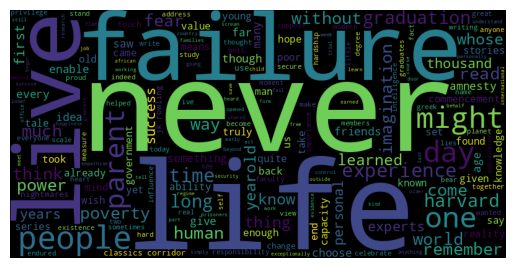

In [38]:
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Eliminar caracteres raros y números
texto_limpio = re.sub(r'[^a-zA-Z\s]', '', texto_lower)

# Tokenizar de nuevo
palabras_limpias = word_tokenize(texto_limpio)

# Quitar stopwords
palabras_filtradas = [p for p in palabras_limpias if p not in stop_words]

# Unir texto limpio
texto_final = " ".join(palabras_filtradas)

# Crear nube de palabras
wordcloud = WordCloud(width=800, height=400).generate(texto_final)

# Mostrar
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

### 2.3 Usando el texto que conseguiste en el punto 1).



#### 2.3.1 Limpia y preprocesa el texto, descomponelo en oraciones, arma una matriz documento-vocabulario.


In [39]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import CountVectorizer

nltk.download('punkt')
nltk.download('stopwords')

# Stopwords
stop_words = set(stopwords.words('english'))

# 1. Separar en oraciones
oraciones = sent_tokenize(texto)

# 2. Limpiar cada oración
oraciones_limpias = []

for oracion in oraciones:
    oracion = oracion.lower()  # minúsculas
    oracion = re.sub(r'[^a-zA-Z\s]', '', oracion)  # quitar caracteres raros

    palabras = word_tokenize(oracion)
    palabras_filtradas = [p for p in palabras if p not in stop_words]

    oracion_limpia = " ".join(palabras_filtradas)
    oraciones_limpias.append(oracion_limpia)

# 3. Crear matriz documento-vocabulario
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(oraciones_limpias)

# 4. Mostrar como tabla
matriz_doc_vocab = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

print("Dimensión de la matriz:", matriz_doc_vocab.shape)
matriz_doc_vocab.head()

Dimensión de la matriz: (131, 927)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,abandon,ability,able,academic,accounts,achievable,achieve,achievement,acknowledges,acquisition,...,wracked,write,writing,written,wrong,wrote,yearold,years,yet,young
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



#### 2.3.2 Determina la longitud de tu vocabulario.

In [40]:
vocabulario = vectorizer.get_feature_names_out()

print(len(vocabulario))

927



#### 2.3.3. Aplica TF-IDF a tu matriz documento-vocabulario

In [41]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Crear vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# use las  oraciones limpias
X_tfidf = tfidf_vectorizer.fit_transform(oraciones_limpias)

# Convertir a DataFrame
tfidf_df = pd.DataFrame(
    X_tfidf.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

# Mostrar dimensión
print("Dimensión de la matriz TF-IDF:", tfidf_df.shape)

# Mostrar primeras filas
tfidf_df.head()

Dimensión de la matriz TF-IDF: (131, 927)


,abandon,ability,able,academic,accounts,achievable,achieve,achievement,acknowledges,acquisition,...,wracked,write,writing,written,wrong,wrote,yearold,years,yet,young
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.363948,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


#Explica el formato de tu matriz resultante: documentos, vocabulario, tamaño. Brinda tus conclusiones.


La matriz TF-IDF tiene como filas las 131 oraciones del discurso de J.K. Rowling (documentos) y como columnas las 927 palabras únicas del vocabulario. Cada valor representa la importancia de una palabra en una oración.

# Conclusiones

Agregue aquí sus conclusiones sobre este trabajo práctico. Puede ser también parte del texto que posteará en el foro.

En este trabajo aprendí a extraer texto de una página web mediante web scraping y a preprocesarlo eliminando elementos innecesarios. También aprendí a representar el texto como datos usando matrices y técnicas como TF-IDF para identificar las palabras más importantes.


# Anexo, código de ejemplo del uso de wordcloud

Instalar e importar la librería

In [42]:
# instalar wordcloud
!pip install wordcloud


In [43]:

# Importar librerías
from wordcloud import WordCloud
import matplotlib.pyplot as plt


In [44]:

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Crear un objeto WordCloud
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)


Mostramos la imagen generada

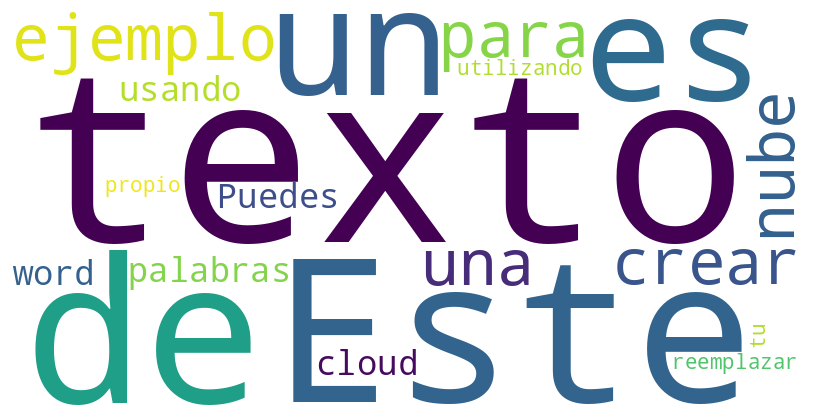

In [45]:

# mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

Modificamos el ejemplo anterior agregando palabras en español que no queremos que considere para crear la nube de palabras. Estas son las stop_words



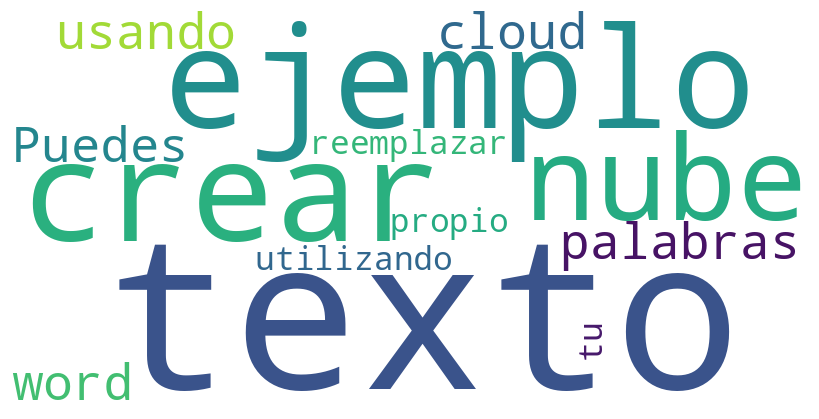

In [46]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

# Texto de ejemplo
text = "Este es un texto de ejemplo para crear una nube de palabras usando word cloud. Puedes reemplazar este texto utilizando tu propio texto."

# Definir stopwords en español
stopwords_es = set(STOPWORDS)
stopwords_es.update(["con", "que", "los", "para", "un", "una", "el", "la", "en", "y", "o", "de", "a", "se", "es", "al", "como", "por", "no", "su", "más", "pero", "si", "este", "esta", "eso", "esa", "todo", "todos", "todas", "cada", "cual", "cualquier", "algo", "alguna", "algún", "ningún", "ninguna", "ninguno", "otro", "otros", "otras", "sobre", "entre", "durante", "desde", "hasta", "también", "así", "mismo", "misma", "mismo", "misma", "tan", "tanto", "tanta", "muy", "poco", "poca", "poco", "nada", "solo", "sola", "solo", "sola", "siempre", "nunca", "jamás", "casi", "aproximadamente", "cerca", "lejos", "antes", "después", "ahora", "hoy", "ayer", "mañana", "luego", "mientras", "mientras tanto", "después de", "antes de", "durante", "sin", "aunque", "a pesar de", "debido a", "gracias a", "por qué", "cómo", "dónde", "cuándo", "quién", "qué", "cuál"])

# Crear un objeto WordCloud con stopwords en español
wordcloud = WordCloud(width=800, height=400, background_color="white", stopwords=stopwords_es).generate(text)

# Mostramos la imagen generada
plt.figure(figsize=(8, 8), facecolor=None)
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()
